# 040304: mean-reversion strategy on a USD SOFR swap (ARBS)

Ported from gs_quant's `040304_strategy_mean_reversion` notebook (DESIGN.md Appendix B), pricing
against the live ARBS Eris curve store through
`configs/assets/usd_sofr_ois_interest_rate_swap.yaml` instead of the toy rates world. From
`action = ...` onwards the code is identical to the gs notebook and to the toy version
(`notebooks/src/040304_mean_reversion_toy.py`): buy/sell a 10y USD payer whenever the 10y par
rate strays from its own rolling mean.

Running this imports ARBS, which needed the user's approval (P5.2, granted and run 2026-09-28;
see docs/v2/LIVE_ARBS_REPORT.md). The dates below are chosen from the config's documented
coverage (`configs/assets/usd_sofr_ois_interest_rate_swap.yaml`'s description:
2020-07-01..2026-08-20, dense from 2021-01-04) so a run has real data across the whole window.

In [1]:
# Only needed if you open this notebook directly in Jupyter with no PYTHONPATH set (tools/nb_build.py
# sets PYTHONPATH=src for its own kernel subprocess, so this is redundant but harmless there).
import sys

sys.path.append(r"C:\Users\chris\clee\gsquant-temp-claude\pricebt-v2\src")

In [2]:
from datetime import date, datetime

import pandas as pd

from pricebt.backtests.actions import AddTradeAction
from pricebt.backtests.data_sources import GenericDataSource, MissingDataStrategy
from pricebt.backtests.generic_engine import GenericEngine
from pricebt.backtests.strategy import Strategy
from pricebt.backtests.triggers import MeanReversionTrigger, MeanReversionTriggerRequirements
from pricebt.common import Currency, PayReceive
from pricebt.data import measure_series
from pricebt.instrument import IRSwap
from pricebt.risk import Price
from pricebt.session import PricebtSession

PricebtSession.use(assets=["configs/assets/usd_sofr_ois_interest_rate_swap.yaml"])  # replaces GsSession.use(...)

`start_date` is the first date the config's ARBS source is dense (decision 0.2). `end_date` stops
short of `datetime.today().date()` (as the gs notebook would use): a full scan of the config's
`_LAST_SAFE`-bounded range found 3 dates (2026-05-21, 2026-06-11, 2026-07-28, out of 1469 business
days) where the local ARBS store serves a market whose own `reference_date()` doesn't match the
date requested — a real ARBS local-store data-quality issue the config's `load_market` validation
(R06 s1.6) correctly raises on rather than silently pricing off the wrong curve. Dates past
`_LAST_SAFE` are separately dropped by `PricebtSession`'s `missing_market='drop'` policy, with a
warning, and listed on `backtest.missing_market_dates` — but that policy only covers a market
expression returning `None`, not a raised validation error, so it does not smooth over these 3
dates. `end_date` here stops before the first of them.

In [3]:
start_date = date(2021, 1, 4)
end_date = date(2026, 4, 30)  # avoids 3 known-bad ARBS store dates (2026-05-21, 06-11, 07-28) past this point

swap = IRSwap(pay_or_receive=PayReceive.Pay, termination_date="10y", notional_currency=Currency.USD,
              notional_amount=1e4, fixed_rate="ATM", name="swap_10y")

Replaces the GS `Dataset`: the 10y par rate (bp) of a fresh ATM 10y swap on every business day.

In [4]:
s = measure_series(IRSwap(termination_date="10y", notional_currency="USD"), "par_rate", start_date, end_date, frequency="1b")

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\rateslib\data\fixings.py:3426: RuntimeWarning: invalid value encountered in divide
  r = (v[:-1] / v[1:] - 1) * 100 / dcfs_obs[len(populated) :]


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-01-18 for curve 'USD-SOFR-1D': 2021-01-18 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-02-15 for curve 'USD-SOFR-1D': 2021-02-15 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-05-31 for curve 'USD-SOFR-1D': 2021-05-31 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-07-05 for curve 'USD-SOFR-1D': 2021-07-05 is not a business day in the US government bond market calendar!


...

Dropping ERIS_EOD_LIVE-RL_BASIC point 2025-11-27 for curve 'USD-SOFR-1D': 2025-11-27 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2025-12-25 for curve 'USD-SOFR-1D': 2025-12-25 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2026-01-01 for curve 'USD-SOFR-1D': 2026-01-01 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2026-01-19 for curve 'USD-SOFR-1D': 2026-01-19 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2026-02-16 for curve 'USD-SOFR-1D': 2026-02-16 is not a business day in the US government bond market calendar!


In [5]:
action = AddTradeAction(swap)
data_source = GenericDataSource(s, MissingDataStrategy.fill_forward)
z_score_bound = 2
rolling_mean_window = 30
rolling_std_window = 30
trig_req = MeanReversionTriggerRequirements(data_source, z_score_bound, rolling_mean_window, rolling_std_window)
trigger = MeanReversionTrigger(trig_req, action)
strategy = Strategy(None, trigger)

GE = GenericEngine()
backtest = GE.run_backtest(strategy, start=start_date, end=end_date, frequency="1b", show_progress=True)
backtest.trade_ledger()

Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-01-18 for curve 'USD-SOFR-1D': 2021-01-18 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-02-15 for curve 'USD-SOFR-1D': 2021-02-15 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-05-31 for curve 'USD-SOFR-1D': 2021-05-31 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-07-05 for curve 'USD-SOFR-1D': 2021-07-05 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2021-09-06 for curve 'USD-SOFR-1D': 2021-09-06 is not a business day in the US government bond market calendar!


...

Dropping ERIS_EOD_LIVE-RL_BASIC point 2026-01-19 for curve 'USD-SOFR-1D': 2026-01-19 is not a business day in the US government bond market calendar!


Dropping ERIS_EOD_LIVE-RL_BASIC point 2026-02-16 for curve 'USD-SOFR-1D': 2026-02-16 is not a business day in the US government bond market calendar!


C:\Users\chris\clee\gsquant-temp-claude\pricebt-v2\src\pricebt\backtests\generic_engine.py:207: UserWarning: pricebt: dropped 57 dates with no market data (2021-01-18..2026-02-16); see backtest.missing_market_dates
  warnings.warn(


pricebt: 100%|████████████████████████████| 3995/3995 [09:58<00:00,  6.68step/s]

,Open,Close,Open Value,Close Value,Long Short,Status,Trade PnL
Action1_swap_10y_2021-01-06,2021-01-06,None,-0.0,0,-1,open,None
Action1_swap_10y_2021-01-25,2021-01-25,None,0.0,0,-1,open,None
Action1_swap_10y_2021-02-05,2021-02-05,None,0.0,0,-1,open,None
Action1_swap_10y_2021-04-13,2021-04-13,None,0.0,0,-1,open,None
Action1_swap_10y_2021-04-15,2021-04-15,None,0.0,0,-1,open,None
...,...,...,...,...,...,...,...
Action1_swap_10y_2026-02-10,2026-02-10,None,0.0,0,-1,open,None
Action1_swap_10y_2026-03-11,2026-03-11,None,-0.0,0,-1,open,None
Action1_swap_10y_2026-03-20,2026-03-20,None,0.0,0,-1,open,None
Action1_swap_10y_2026-04-17,2026-04-17,None,-0.0,0,-1,open,None


In [6]:
backtest.result_summary

,Price,Cumulative Cash,Transaction Costs,Total
2021-01-04,0.000000e+00,0.000000e+00,0.0,0.000000
2021-01-05,0.000000e+00,0.000000e+00,0.0,0.000000
2021-01-06,2.273737e-13,-2.273737e-13,0.0,0.000000
2021-01-07,-3.464575e+01,-2.273737e-13,0.0,-34.645748
2021-01-08,-7.038473e+01,-2.273737e-13,0.0,-70.384732
...,...,...,...,...
2026-04-24,-2.099660e+02,3.069545e-12,0.0,-209.966045
2026-04-27,-2.086387e+02,3.069545e-12,0.0,-208.638667
2026-04-28,-2.093271e+02,3.069545e-12,0.0,-209.327082
2026-04-29,-2.068034e+02,3.069545e-12,0.0,-206.803409


<Axes: title={'center': 'Performance'}>

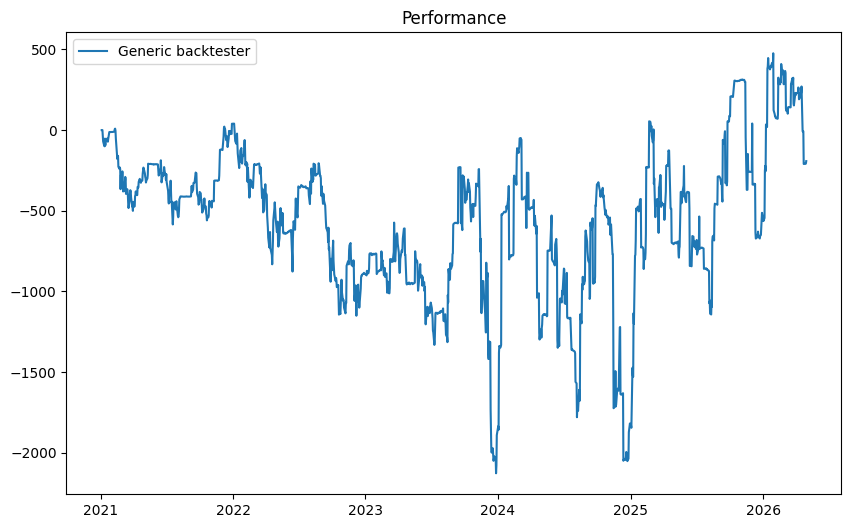

In [7]:
pd.DataFrame({"Generic backtester": backtest.result_summary["Cumulative Cash"] + backtest.result_summary[Price]}).plot(
    figsize=(10, 6), title="Performance")